importing all relevant libraries

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import jax

In [15]:
from pathlib import Path
from typing import List

import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np
import optax  # pip install optax
import pandas as pd
import seaborn as sns
from beartype import beartype
from jaxtyping import Array, Int
from scipy.stats import zscore
from torch.utils.data import DataLoader, RandomSampler, random_split
from sklearn import preprocessing




In [ ]:
jax.devices()

[CpuDevice(id=0)]

Loading our custom dataset

In [3]:

class Dataset:
    def __init__(self, transform=None, columns=List, data_path=Path) -> None:
        self.data = pd.read_csv(data_path)

        self.sequences = self.data[columns[0]].tolist()
        self.aff_Vals = np.array(self.data[columns[1]])
        self.transform = transform
        self.max_seq = 0

        for seq in self.sequences:
            if self.max_seq < len(seq):
                self.max_seq = len(seq)

    def __len__(self) -> int:
        return len(self.sequences)


    def __getitem__(self, idx=Int) -> tuple[Array, float]:
        seq = self.sequences[idx]
        affVal = self.aff_Vals[idx]
        if self.transform:
            padd_len = self.max_seq - len(seq)
            seq = self.transform([seq + "." * padd_len])[0]

            seq = np.array(seq)

        return seq, affVal

In [4]:
Dataset_training = Dataset(data_path=Path("/home/kunzj/dataset/final_csv/train.csv"), transform=esm2quinox.tokenise, columns=['Sequence','delta_G'])

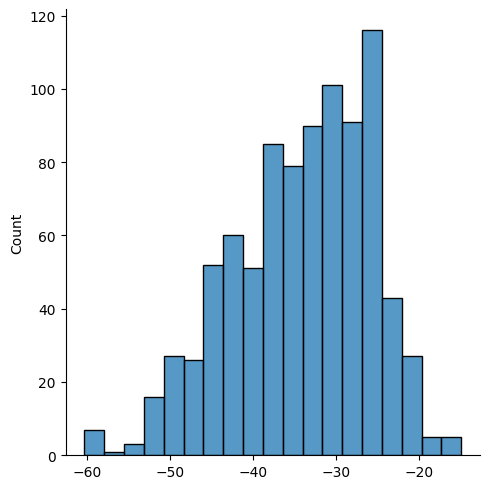

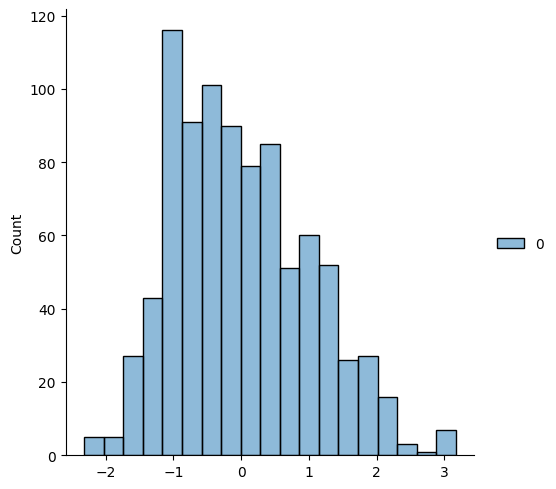

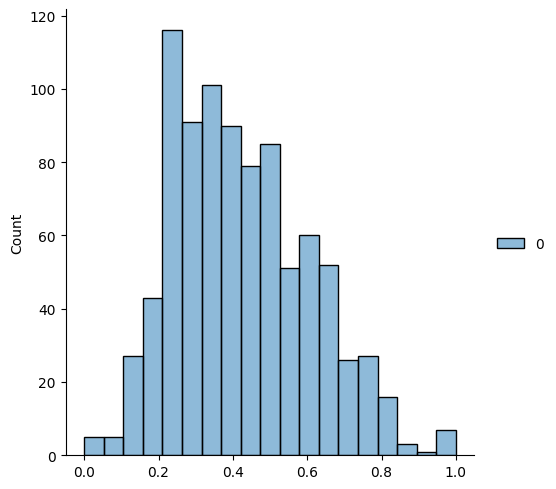

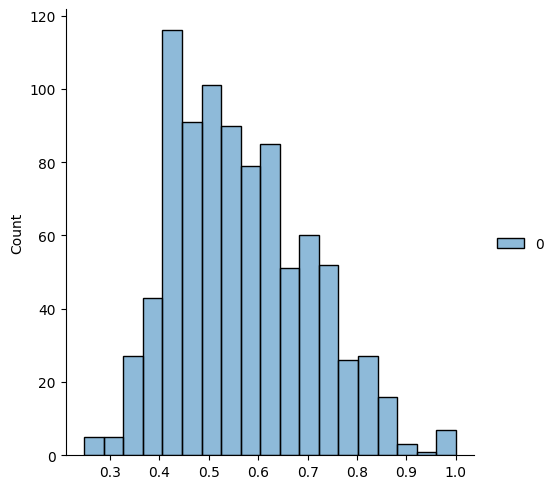

In [5]:
sns.displot(Dataset_training.aff_Vals)

data= np.array(-1* Dataset_training.aff_Vals).reshape(-1,1)
standard_scaler = preprocessing.StandardScaler().fit(data)
ds_stand_scaled = standard_scaler.transform(data)
sns.displot(ds_stand_scaled)


minmax_scaler = preprocessing.MinMaxScaler().fit(data)
ds_minmax_scaled = minmax_scaler.transform(data)
sns.displot(ds_minmax_scaled)


data= np.array(-1* Dataset_training.aff_Vals).reshape(-1,1)
ds_own_scaled = data / max(data)
sns.displot(ds_own_scaled)


In [6]:
Dataset_training.aff_Vals = np.array(ds_minmax_scaled)

In [4]:
training_DataLoader = DataLoader(Dataset_training,batch_size=5)

NameError: name 'Dataset_training' is not defined

In [19]:
data_key, model_key, init_key = jrandom.split(jrandom.PRNGKey(0), 3)

In [20]:
test_seq1 = jnp.array([17, 17, 8, 6, 10, 4, 7, 13, 20, 20, 4, 15, 4, 4, 16])
test_seq2 = jnp.array([17, 17, 8, 6, 4, 4, 7, 5, 20, 11, 4, 15, 19, 3, 16])
test_in = jnp.array((test_seq1, test_seq2))
test_in.shape

(2, 15)

In [21]:
class AFF_PREDICTOR(eqx.Module):
    esm2: esm2quinox.ESM2
    conv1: eqx.nn.Conv1d
    conv2: eqx.nn.Conv1d
    conv3: eqx.nn.Conv1d
    batchnorm1: eqx.nn.BatchNorm
    batchnorm2: eqx.nn.BatchNorm
    batchnorm3: eqx.nn.BatchNorm
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    relu: jax.nn.relu

    def __init__(self, model, key):
        key1, key2, key3, key4, key5 = jr.split(key, 5)
        self.esm2 = model  # (num_layers=3, embed_size=32, num_heads=2, token_dropout=False, key=key)
        # output size is 480
        self.conv1 = eqx.nn.Conv1d(
            in_channels=320,
            out_channels=256,
            kernel_size=5,
            padding="SAME",
            stride=1,
            key=key1,
        )
        self.conv2 = eqx.nn.Conv1d(
            in_channels=256,
            out_channels=128,
            kernel_size=5,
            padding="SAME",
            stride=1,
            key=key2,
        )
        self.conv3 = eqx.nn.Conv1d(
            in_channels=128,
            out_channels=64,
            kernel_size=5,
            padding="SAME",
            stride=1,
            key=key3,
        )
        self.batchnorm1 = eqx.nn.BatchNorm(256, axis_name="batch")
        self.batchnorm2 = eqx.nn.BatchNorm(128, axis_name="batch")
        self.batchnorm3 = eqx.nn.BatchNorm(64, axis_name="batch")
        self.linear1 = eqx.nn.Linear(in_features=64, out_features=32, key=key4)
        self.linear2 = eqx.nn.Linear(in_features=32, out_features=1, key=key5)
        self.relu = jax.nn.relu

    def __call__(self, tokens, state):
        # out_esm = jax.vmap(self.model,in_axes=0,out_axes=0)(tokens).hidden  # (batch, length, 320)
        out_esm = self.esm2(tokens).hidden  # (batch, length, 320)
        out_esm_ord = jnp.transpose(out_esm, (1, 0))  # (batch, 320, length)
        out_esm_ord = jnp.array(out_esm_ord)
        out_conv1 = self.conv1(out_esm_ord)
        out_batchn1, state1 = self.batchnorm1(out_conv1, state)
        out_conv2 = self.conv2(out_batchn1)
        out_batchn2, state2 = self.batchnorm2(out_conv2, state1)
        out_conv3 = self.conv3(out_batchn2)
        out_batchn3, state3 = self.batchnorm3(out_conv3, state2)
        out_pool = jnp.mean(out_batchn3, axis=1, keepdims=True)
        out_pool_ord = out_pool.squeeze()
        out_fc1 = self.linear1(out_pool_ord)
        out_fc2 = self.linear2(out_fc1)
        out = out_fc2 #self.relu(out_fc2)
        return out, state3


In [27]:
torch_model, _ = esm.pretrained.esm2_t12_35M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, state = eqx.nn.make_with_state(AFF_PREDICTOR)(
    model=model_esm2, key=model_key
)

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t12_35M_UR50D.pt" to /home/jkunz/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t12_35M_UR50D-contact-regression.pt" to /home/jkunz/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D-contact-regression.pt


/home/jkunz/master_uni_hd/internship_amsterdam/work/lib/python3.10/site-packages/equinox/nn/_batch_norm.py:132: UserWarning: When `eqx.nn.BatchNorm(..., mode=...)` is unspecified it defaults to 'ema', for backward compatibility. This typically has a performance impact, and for new code the user is encouraged to use 'batch' instead. See `https://github.com/patrick-kidger/equinox/issues/659`.
  warnings.warn(


In [1]:
from transformers import AutoTokenizer
from transformers import PreTrainedTokenizer
from transformers import AutoModel

In [2]:
tokenizer= AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [3]:
len('KJSDNSNDJLNSDNWIUQEO')

20

In [4]:
input_prot_model = tokenizer(['KJSDNSNDJLNSDNWIUQEO'], return_tensors="pt",padding=True)
input_prot_model

{'input_ids': tensor([[ 0, 15,  3,  8, 13, 17,  8, 17, 13,  3,  4, 17,  8, 13, 17, 22, 12, 26,
         16,  9, 28,  2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [10]:
import jax.numpy as jnp
equinox_input_prot_model= jnp.array(input_prot_model['input_ids'])

In [6]:
protein_model =AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
protein_model(input_ids=input_prot_model['input_ids'],attention_mask = input_prot_model['attention_mask'])['pooler_output'].shape

torch.Size([1, 480])

In [31]:
protein_model(input_ids=input_prot_model['input_ids'],attention_mask = input_prot_model['attention_mask'])

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.1633, -0.1998,  0.1229,  ..., -0.5391, -0.0247,  0.1561],
         [-0.5494,  0.0128,  0.0835,  ..., -0.3028,  0.1122,  0.1517],
         [-0.2412,  0.1441, -0.0032,  ..., -0.0704, -0.1027,  0.1106],
         ...,
         [ 0.0049,  0.1491,  0.3358,  ..., -0.2508, -0.1081, -0.1263],
         [-0.0495,  0.1278,  0.1590,  ...,  0.0331, -0.0771,  0.0702],
         [-0.2663,  0.3144,  0.3534,  ..., -0.3834, -0.1677, -0.1406]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 0.0898, -0.0017, -0.1861, -0.0361, -0.0335,  0.0493,  0.1853, -0.2546,
         -0.0887,  0.1132,  0.0300, -0.1198,  0.1523,  0.2820,  0.3082, -0.0018,
          0.0789,  0.2698,  0.3182,  0.1901, -0.0714,  0.0710,  0.1049, -0.1893,
          0.1952,  0.1403, -0.0958, -0.0178,  0.0787,  0.1596, -0.0252,  0.0489,
         -0.1594, -0.0420, -0.1500,  0.3378,  0.2143,  0.0907,  0.0586, -0.1990,
          0.1704,  0.0710,  0.03

In [30]:
protein_model

EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 480, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-11): 12 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=480, out_features=480, bias=True)
            (key): Linear(in_features=480, out_features=480, bias=True)
            (value): Linear(in_features=480, out_features=480, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=480, out_features=480, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=480, out_features=1920, bias=True)
        )
        (output): EsmOutput(
      

In [25]:
equinox_input_prot_model[0]

Array([ 0, 15,  3,  8, 13, 17,  8, 17, 13,  3,  4, 17,  8, 13, 17, 22, 12,
       26, 16,  9, 28,  2], dtype=int32)

In [28]:
model_esm2(equinox_input_prot_model[0]).hidden

Array([[-0.16326965, -0.19983359,  0.1229044 , ..., -0.5391144 ,
        -0.02471784,  0.15608738],
       [-0.5494198 ,  0.01276438,  0.083519  , ..., -0.3027949 ,
         0.11219407,  0.15167168],
       [-0.24120536,  0.14405641, -0.00323452, ..., -0.07042196,
        -0.1026535 ,  0.11065444],
       ...,
       [ 0.00489853,  0.14912349,  0.33581558, ..., -0.2507963 ,
        -0.10810886, -0.12626721],
       [-0.0494968 ,  0.12777305,  0.15903091, ...,  0.03306562,
        -0.07710867,  0.07017217],
       [-0.26632953,  0.3143603 ,  0.35338205, ..., -0.38339055,
        -0.1677141 , -0.14063624]], dtype=float32)

In [ ]:

@eqx.filter_value_and_grad(has_aux=True)
def compute_loss(model, state, x, y):
    pred_y, state = jax.vmap(
        model, axis_name="batch", in_axes=(0, None), out_axes=(0, None)
    )(x, state)
    # trains with MSE
    
    return jnp.mean((pred_y - y) ** 2), state

def eval_step(model, state, x, y):
        pred_y, state = jax.vmap(
        model, axis_name="batch", in_axes=(0, None), out_axes=(0, None)
    )(x, state)
        return jnp.mean((pred_y - y) ** 2), pred_y
    


@eqx.filter_jit
def make_step(model, state, x, y, opt_state, optim):
    (loss, state), grads = compute_loss(model, state, x, y)
    # print(f'grads:{grads}')
    mse, pred_y = compute_loss(model, state, x, y)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, state, opt_state, pred_y, mse


optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))
step = 1
losses = []
val_mse = []

for x, y in training_DataLoader:
    x = jnp.array(x)
    y = jnp.array(y)
    # print(x.shape)
    loss, model_aff, state, opt_state, pred_y, mse = make_step(model_aff, state, x, y, opt_state, optim)
    loss = loss.item()
    val_mse.appen(mse)
    
    print(f"step={step}, loss={'%.2f' % loss}, loss={'%.2f' % mse.item()}")
    
    step += 1


step=1, loss=0.46
step=2, loss=2.18
step=3, loss=9.78
step=4, loss=367.57
step=5, loss=228.24
step=6, loss=88.55
step=7, loss=51.14
step=8, loss=10.45
step=9, loss=33.60
step=10, loss=2.34
step=11, loss=18.97
step=12, loss=6.20
step=13, loss=9.66
step=14, loss=15.67
step=15, loss=2.86
step=16, loss=14.70
step=17, loss=0.43
step=18, loss=2.41
step=19, loss=3.12
step=20, loss=0.01
step=21, loss=1.84
step=22, loss=1.05
step=23, loss=0.09
step=24, loss=0.39
step=25, loss=0.77
step=26, loss=0.47
step=27, loss=0.21
step=28, loss=0.12
step=29, loss=0.31
step=30, loss=0.31
step=31, loss=0.20
step=32, loss=0.03
step=33, loss=0.11
step=34, loss=0.45
step=35, loss=0.03
step=36, loss=0.03
step=37, loss=0.05
step=38, loss=0.01
step=39, loss=0.00
step=40, loss=0.00
step=41, loss=0.04
step=42, loss=0.05
step=43, loss=0.06
step=44, loss=0.00
step=45, loss=0.09
step=46, loss=0.02
step=47, loss=0.05
step=48, loss=0.01
step=49, loss=0.05
step=50, loss=0.03
step=51, loss=0.02
step=52, loss=0.02
step=53, l

In [13]:
Dataset_test = Dataset(data_path=Path("/home/kunzj/dataset/final_csv/test.csv"), transform=esm2quinox.tokenise, columns=['Sequence','delta_G'])
Dataset_test.aff_Vals = minmax_scaler.transform(np.array(-1* Dataset_test.aff_Vals).reshape(-1,1))
test_DataLoader = DataLoader(Dataset_test,batch_size=1)

In [14]:
Dataset_test.aff_Vals.shape

(95, 1)

In [15]:
inference_model = eqx.nn.inference_mode(model_aff)
inference_model = eqx.Partial(inference_model, state=state)


@eqx.filter_jit
def evaluate(model, x):
    pred_y, _ = jax.vmap(model)(x)
    return pred_y


mses = []
true_y_list = []
pred_y_list = []
for x, y in test_DataLoader:
    x = jnp.array(x)
    y = jnp.array(y)
    pred_y = evaluate(inference_model, x)
    mse = (pred_y - y).mean()
    #print(pred_y)
    pred_y = float(pred_y.item()) 
    y = float(y.item()) 
    mses.append(mse)
    true_y_list.append(y)
    pred_y_list.append(pred_y)
    print(f" mse={'%.2f' % mse},pred_y={'%.2f' % pred_y}, true_y={'%.2f' % y}")

values = pd.DataFrame({"true": true_y_list, "pred": pred_y_list})


 mse=-0.18,pred_y=0.16, true_y=0.34
 mse=-0.05,pred_y=0.13, true_y=0.18
 mse=-0.12,pred_y=0.16, true_y=0.27
 mse=-0.32,pred_y=0.07, true_y=0.39
 mse=-0.40,pred_y=0.00, true_y=0.40
 mse=-0.18,pred_y=0.19, true_y=0.37
 mse=-0.43,pred_y=0.19, true_y=0.62
 mse=-0.26,pred_y=0.20, true_y=0.46
 mse=-0.04,pred_y=0.17, true_y=0.21
 mse=-0.42,pred_y=0.07, true_y=0.49
 mse=-0.43,pred_y=0.01, true_y=0.44
 mse=-0.11,pred_y=0.17, true_y=0.28
 mse=-0.09,pred_y=0.15, true_y=0.25
 mse=-0.12,pred_y=0.10, true_y=0.22
 mse=-0.12,pred_y=0.10, true_y=0.22
 mse=-0.57,pred_y=0.10, true_y=0.68
 mse=-0.60,pred_y=0.08, true_y=0.68
 mse=-0.45,pred_y=0.14, true_y=0.59
 mse=-0.46,pred_y=0.15, true_y=0.62
 mse=0.00,pred_y=0.11, true_y=0.11
 mse=-0.22,pred_y=0.13, true_y=0.35
 mse=-0.12,pred_y=0.21, true_y=0.33
 mse=-0.26,pred_y=0.20, true_y=0.46
 mse=-0.40,pred_y=0.09, true_y=0.49
 mse=-0.21,pred_y=0.11, true_y=0.32
 mse=-0.25,pred_y=0.17, true_y=0.42
 mse=-0.28,pred_y=0.19, true_y=0.47
 mse=-0.07,pred_y=0.17, true_

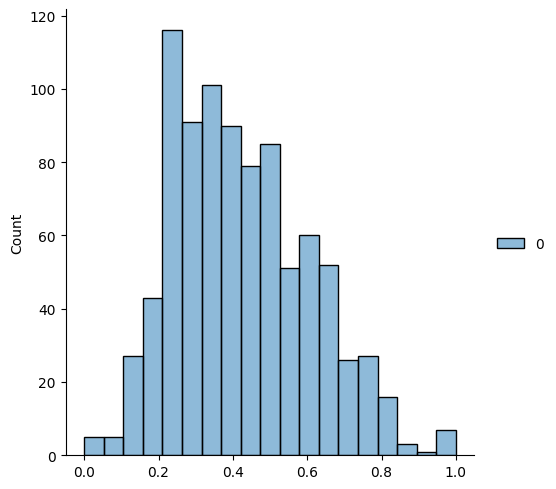

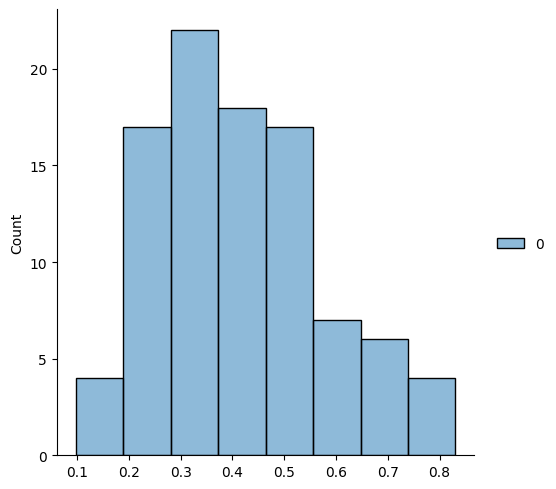

: 

In [ ]:
sns.displot(Dataset_training.aff_Vals)
sns.displot(Dataset_test.aff_Vals)

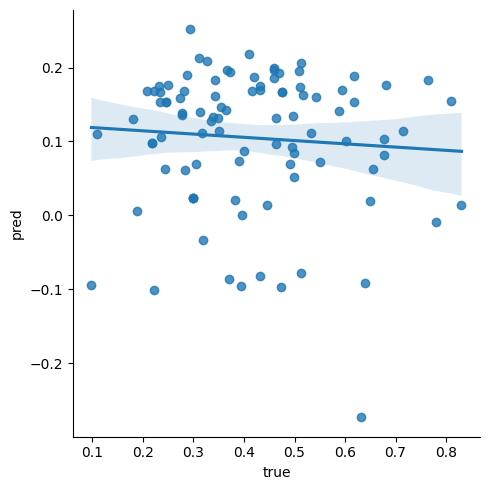

In [16]:
sns.lmplot(data=values, x="true", y="pred")

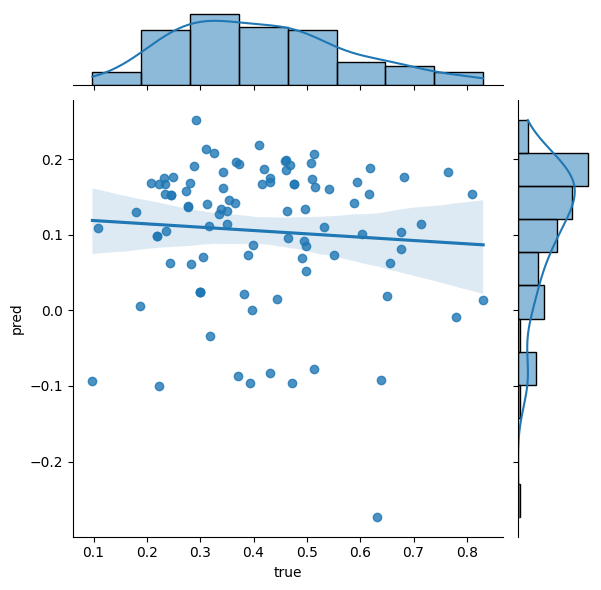

In [17]:
sns.jointplot(
    data=values,
    x="true",
    y="pred",
    kind="reg",  # adds regression line + scatter
    height=6,
)

In [18]:
from scipy.stats import pearsonr, spearmanr

In [19]:
spearmanr(values["true"], values["pred"])

SignificanceResult(statistic=np.float64(-0.028011380944287838), pvalue=np.float64(0.7875759351306265))

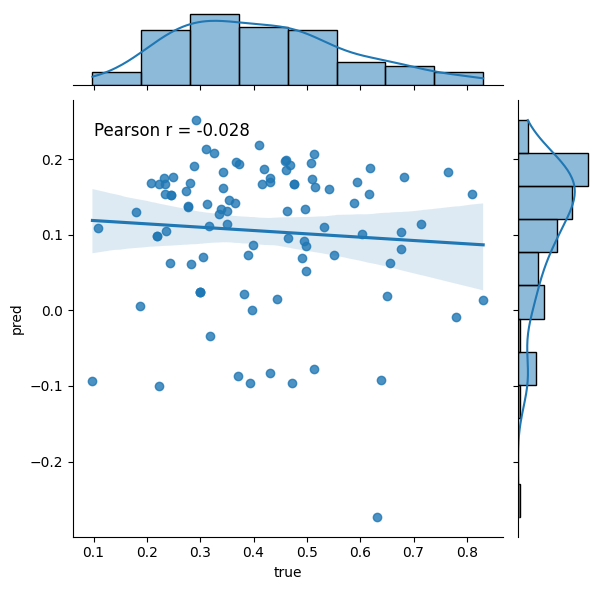

In [20]:
g = sns.jointplot(
    data=values,
    x="true",
    y="pred",
    kind="reg",  # adds regression line + scatter
    height=6,
)

# Add correlation text manually
r, _ = spearmanr(values["true"], values["pred"])
g.ax_joint.text(
    0.05,
    0.95,
    f"Pearson r = {r:.3f}",
    transform=g.ax_joint.transAxes,
    fontsize=12,
    verticalalignment="top",
)

plt.show()

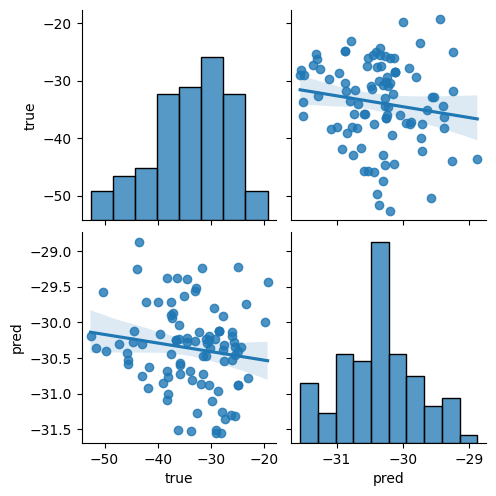

In [93]:
sns.pairplot(values, kind="reg")

In [ ]:
r, _ = pearsonr(values["true"], values["pred"])
print(f"Correlation (r): {r:.3f}")

Correlation (r): -0.150


### other things

In [ ]:
import numpy as np

seq_whole = np.array(
    [
        [
            [
                0.04753593,
                0.05057031,
                0.08087008,
                0.06377603,
                0.0,
                0.05259847,
                0.05418196,
                0.06199308,
                0.062637,
                0.03266549,
                0.04232723,
                0.05430273,
                0.04261426,
                0.04441427,
                0.04710583,
                0.06925543,
                0.06008266,
                0.04586043,
                0.04602345,
                0.04118538,
            ],
            [
                0.04588729,
                0.05403269,
                0.06993538,
                0.05520252,
                0.0,
                0.05730417,
                0.05301455,
                0.05251888,
                0.05100059,
                0.04264713,
                0.05152847,
                0.05675201,
                0.05222774,
                0.04574076,
                0.05341069,
                0.05124507,
                0.05382579,
                0.0563967,
                0.05120694,
                0.04612265,
            ],
            [
                0.04854855,
                0.05771248,
                0.05826642,
                0.05705515,
                0.0,
                0.05316003,
                0.04889608,
                0.04908446,
                0.06007947,
                0.05102956,
                0.04619207,
                0.04882776,
                0.04812585,
                0.04761496,
                0.0597238,
                0.06652014,
                0.0603663,
                0.04505509,
                0.04545581,
                0.04828609,
            ],
            [
                0.03596907,
                0.04836942,
                0.04072737,
                0.04219091,
                0.0,
                0.03347485,
                0.03015434,
                0.35767764,
                0.0324612,
                0.02482151,
                0.03434101,
                0.03983008,
                0.02782086,
                0.03433514,
                0.04072155,
                0.03993359,
                0.02628884,
                0.05425983,
                0.03103258,
                0.02559021,
            ],
            [
                0.05688364,
                0.07877856,
                0.04602344,
                0.05427643,
                0.0,
                0.05499562,
                0.05372373,
                0.04420657,
                0.05134294,
                0.04579633,
                0.05059721,
                0.07067424,
                0.05077329,
                0.03844669,
                0.03966353,
                0.06142368,
                0.05512782,
                0.0415534,
                0.05596722,
                0.0497457,
            ],
            [
                0.0621328,
                0.04943526,
                0.04855771,
                0.04864206,
                0.0,
                0.04751828,
                0.04483894,
                0.05489281,
                0.04271834,
                0.05941689,
                0.07698803,
                0.04850633,
                0.05725068,
                0.05009161,
                0.05337518,
                0.04318566,
                0.04618002,
                0.05381248,
                0.05417022,
                0.0582867,
            ],
            [
                0.05741967,
                0.03464946,
                0.03946917,
                0.04442683,to
                0.0,
                0.04149988,
                0.05703784,
                0.04462444,
                0.04744708,
                0.06762152,
                0.04959434,
                0.04057947,
                0.054348,
                0.06028864,
                0.06512327,
                0.04419743,
                0.05135423,
                0.03824255,
                0.04875287,
                0.11332323,
            ],
            [
                0.04206431,
                0.04352366,
                0.07165087,
                0.10956626,
                0.0,
                0.05184281,
                0.0520242,
                0.05007925,
                0.0518999,
                0.03928814,
                0.04885809,
                0.05234672,
                0.03666163,
                0.04867583,
                0.05091989,
                0.04491124,
                0.04484379,
                0.06995704,
                0.04798845,
                0.04289792,
            ],
            [
                0.04714848,
                0.05059556,
                0.05378606,
                0.04013665,
                0.0,
                0.05809423,
                0.04740741,
                0.04131588,
                0.05158305,
                0.0605159,
                0.05019347,
                0.05804048,
                0.08372413,
                0.0454518,
                0.04718705,
                0.05654435,
                0.0627198,
                0.04752672,
                0.04395934,
                0.05406965,
            ],
            [
                0.05835221,
                0.04656969,
                0.03882282,
                0.03568652,
                0.0,
                0.04067462,
                0.0368121,
                0.04467167,
                0.03288044,
                0.06900549,
                0.09119344,
                0.04349284,
                0.09261602,
                0.05169144,
                0.04935154,
                0.04000964,
                0.04885388,
                0.06158272,
                0.0514969,
                0.06623608,
            ],
            [
                0.05069882,
                0.04779418,
                0.04665154,
                0.03514581,
                0.0,
                0.04213797,
                0.04029228,
                0.05315638,
                0.03941705,
                0.06550182,
                0.10023763,
                0.0408574,
                0.05984429,
                0.05843524,
                0.05602606,
                0.04499338,
                0.05810954,
                0.05513897,
                0.05009833,
                0.05546331,
            ],
            [
                0.04612637,
                0.06808052,
                0.05771927,
                0.04670283,
                0.0,
                0.05747935,
                0.05427664,
                0.05011707,
                0.05689468,
                0.04287224,
                0.0449973,
                0.07998395,
                0.04745997,
                0.04306599,
                0.04952521,
                0.05719078,
                0.05667511,
                0.04500394,
                0.04831884,
                0.04750995,
            ],
            [
                0.05028845,
                0.04424794,
                0.04565488,
                0.03868665,
                0.0,
                0.04381201,
                0.04447179,
                0.03945025,
                0.04090936,
                0.07565924,
                0.0833963,
                0.04749558,
                0.05182395,
                0.05918542,
                0.04606074,
                0.0442603,
                0.05791,
                0.06222415,
                0.06009846,
                0.06436453,
            ],
            [
                0.05058066,
                0.04379888,
                0.04121409,
                0.03880871,
                0.0,
                0.04458053,
                0.03877224,
                0.04834434,
                0.03780167,
                0.07327534,
                0.09383251,
                0.03990548,
                0.06631966,
                0.069607,
                0.05026026,
                0.0383432,
                0.04293617,
                0.06743933,
                0.05131191,
                0.06286804,
            ],
            [
                0.0520292,
                0.05359969,
                0.0506839,
                0.04655393,
                0.0,
                0.07617893,
                0.05855718,
                0.04894573,
                0.04838149,
                0.04786865,
                0.04635216,
                0.06087087,
                0.06776878,
                0.04424573,
                0.04334945,
                0.06537236,
                0.05219118,
                0.0437387,
                0.04546945,
                0.04784269,
            ],
        ]
    ]
)